In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

This project aims to classify Alzheimer’s disease using clinical and cognitive test data. Machine learning techniques were used to build a classification model that predicts whether a patient is cognitively normal, has mild cognitive impairment, or has Alzheimer’s disease.

In [24]:
# Load data from Excel sheets
diagnosis_df = pd.read_excel("../data/CSI_7_MAL_2324_CW_resit_data.xlsx", sheet_name="Diagnosis target")
diagnosis_df.head()

,RID,Test_data,Diagnosis,FDG_PET
0,2,0,CN,1.36926
1,3,0,AD,1.09079
2,4,1,LMCI,NaN
3,5,0,CN,1.29799
4,6,0,LMCI,NaN


In [25]:
cognitive_scores_df = pd.read_excel("../data/CSI_7_MAL_2324_CW_resit_data.xlsx", sheet_name="Cognitive score")
cognitive_scores_df.head()

,RID,Test_data,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting
0,2,0,0.0,10.67,18.67,28,44.0,4.0,6.0,54.5455
1,3,0,4.5,22.00,31.00,20,22.0,1.0,4.0,100.0000
2,4,1,1.0,14.33,21.33,27,37.0,7.0,4.0,36.3636
3,5,0,0.0,8.67,14.67,29,37.0,4.0,4.0,44.4444
4,6,0,0.5,18.67,25.67,25,30.0,1.0,5.0,83.3333


In [26]:
data_df = pd.read_excel("../data/CSI_7_MAL_2324_CW_resit_data.xlsx", sheet_name="Data")
data_df.head()

,RID,Test_data,Age,Gender,Year_education,Ethnicity,Race,Marital_status,High_risk_ApoE4,Ventricles,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,74.3,Male,16,Not Hisp/Latino,White,Married,0.0,118233.0,...,0.694,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396
1,3,0,81.3,Male,18,Not Hisp/Latino,White,Married,1.0,84599.0,...,0.591,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304
2,4,1,67.5,Male,10,Hisp/Latino,White,Married,0.0,39605.0,...,0.588,4060,1728,2.18,0.607,11156,3598,2.67,0.631,1338
3,5,0,73.7,Male,16,Not Hisp/Latino,White,Married,0.0,34062.0,...,0.628,5180,1868,2.543,0.709,11579,3387,2.911,0.66,1623
4,6,0,80.4,Female,13,Not Hisp/Latino,White,Married,0.0,39826.0,...,0.631,3078,1241,2.141,0.701,9641,2781,2.9,0.727,1035


# Handling Missing Values 

In [27]:
# Handle missing values in each DataFrame
diagnosis_df.dropna(inplace=True)
cognitive_scores_df.dropna(inplace=True)
data_df.dropna(inplace=True)

In [28]:
merged_df = pd.merge(diagnosis_df, cognitive_scores_df, on='RID', how='inner')
merged_df = pd.merge(merged_df, data_df, on='RID', how ='inner')
merged_df.head()

,RID,Test_data_x,Diagnosis,FDG_PET,Test_data_y,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,CN,1.36926,0,0.0,10.67,18.67,28,44.0,...,0.694,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396
1,3,0,AD,1.09079,0,4.5,22.00,31.00,20,22.0,...,0.591,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304
2,5,0,CN,1.29799,0,0.0,8.67,14.67,29,37.0,...,0.628,5180,1868,2.543,0.709,11579,3387,2.911,0.66,1623
3,8,0,CN,1.27628,0,0.0,5.00,7.00,28,51.0,...,0.541,3435,1412,2.274,0.676,10469,3533,2.601,0.655,2098
4,10,0,AD,1.11881,0,5.0,12.33,24.33,24,20.0,...,0.541,3158,1381,2.175,0.533,10209,3368,2.622,0.611,1046


In [29]:
merged_df.shape

(778, 373)

In [30]:
# Standardize numerical columns
numerical_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
scaler = StandardScaler()
merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])

# Feature Selection

In [31]:
# Select relevant features
selected_features = merged_df.drop(columns=['RID','Test_data'])

# Print the selected features
print("Selected Features:")
selected_features.head()

Selected Features:


,Test_data_x,Diagnosis,FDG_PET,Test_data_y,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,-0.508822,CN,0.903795,-0.508822,-0.871088,0.047685,0.256031,0.239164,0.649928,-0.131430,...,0.694,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396
1,-0.508822,AD,-0.937641,-0.508822,1.697063,1.758719,1.556445,-2.874977,-1.129653,-1.234879,...,0.591,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304
2,-0.508822,CN,0.432508,-0.508822,-0.871088,-0.254351,-0.165839,0.628432,0.083697,-0.131430,...,0.628,5180,1868,2.543,0.709,11579,3387,2.911,0.66,1623
3,-0.508822,CN,0.288947,-0.508822,-0.871088,-0.808587,-0.974774,0.239164,1.216158,0.972018,...,0.541,3435,1412,2.274,0.676,10469,3533,2.601,0.655,2098
4,-0.508822,AD,-0.752354,-0.508822,1.982413,0.298375,0.852977,-1.317906,-1.291434,-0.867063,...,0.541,3158,1381,2.175,0.533,10209,3368,2.622,0.611,1046


In [32]:
# encode categorical variables
for col in selected_features.columns:
    if col != "Diagnosis" and selected_features[col].dtype == "object":
        selected_features[col] = pd.Categorical(selected_features[col]).codes

selected_features.head()

,Test_data_x,Diagnosis,FDG_PET,Test_data_y,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,-0.508822,CN,0.903795,-0.508822,-0.871088,0.047685,0.256031,0.239164,0.649928,-0.131430,...,214,182,187,94,170,726,593,446,98,636
1,-0.508822,AD,-0.937641,-0.508822,1.697063,1.758719,1.556445,-2.874977,-1.129653,-1.234879,...,116,129,276,33,121,377,383,121,135,598
2,-0.508822,CN,0.432508,-0.508822,-0.871088,-0.254351,-0.165839,0.628432,0.083697,-0.131430,...,152,599,376,430,134,568,417,387,109,168
3,-0.508822,CN,0.288947,-0.508822,-0.871088,-0.808587,-0.974774,0.239164,1.216158,0.972018,...,67,69,69,244,101,391,468,150,104,348
4,-0.508822,AD,-0.752354,-0.508822,1.982413,0.298375,0.852977,-1.317906,-1.291434,-0.867063,...,67,31,51,165,4,336,408,160,62,17


In [33]:
# place nan values with mean in FDG column
selected_features["FDG_PET"] = selected_features["FDG_PET"].fillna(selected_features["FDG_PET"].mean())

In [34]:
selected_features.isnull().sum()

Test_data_x                                                     0
Diagnosis                                                       0
FDG_PET                                                         0
Test_data_y                                                     0
CDRSB                                                           0
                                                               ..
Volume (Cortical Parcellation) of RightMiddleTemporal           0
Surface Area of RightMiddleTemporal                             0
Cortical Thickness Average of RightMiddleTemporal               0
Cortical Thickness Standard Deviation of RightMiddleTemporal    0
Volume (WM Parcellation) of FourthVentricle                     0
Length: 371, dtype: int64

# Model Training

In [35]:
# Split the data into features (X) and target variable (y)
X = selected_features.drop(columns=["Diagnosis"])
y = selected_features["Diagnosis"]

In [36]:
# Encode the target variable 'Diagnosis'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

## Train-Test Split

The dataset was split into training and testing sets using an 80/20 split.  
The training set is used to train the machine learning model, while the testing set is used to evaluate how well the model performs on unseen data.

In [37]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

## Model Training

A Random Forest classifier was used for this project.  
Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

In [38]:
# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Train the Random Forest model
rf_classifier.fit(X_train, y_train)

RandomForestClassifier()

## Model Evaluation

The model was evaluated using training accuracy and testing accuracy.  
Accuracy measures the percentage of correct predictions made by the model.  
Comparing training and testing accuracy also helps check whether the model may be overfitting.

In [39]:
# Evaluate the model
train_accuracy = rf_classifier.score(X_train, y_train)
test_accuracy = rf_classifier.score(X_test, y_test)

print("Training Accuracy:", train_accuracy*100)
print("Testing Accuracy:", test_accuracy*100)


Training Accuracy: 100.0
Testing Accuracy: 78.84615384615384


In [42]:
from sklearn.metrics import classification_report

y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

          AD       0.91      0.83      0.87        24
          CN       0.83      0.86      0.85        35
        EMCI       0.71      0.90      0.80        39
        LMCI       0.83      0.75      0.78        51
         SMC       0.00      0.00      0.00         7

    accuracy                           0.79       156
   macro avg       0.66      0.67      0.66       156
weighted avg       0.78      0.79      0.78       156



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.  
It helps identify where the model is making mistakes across the diagnosis categories.

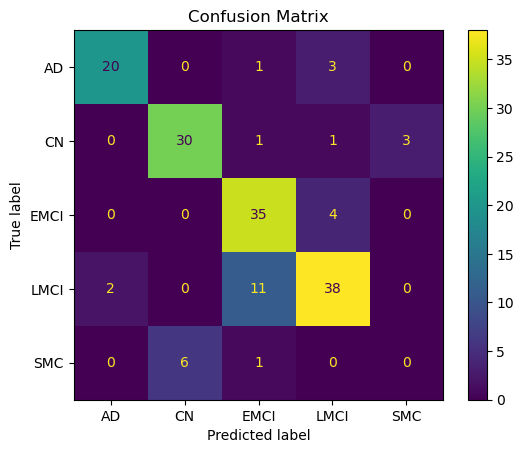

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

Feature importance helps show which input variables contributed most to the model’s predictions.  
This can provide useful insight into which cognitive and clinical measures are most relevant for Alzheimer’s classification.

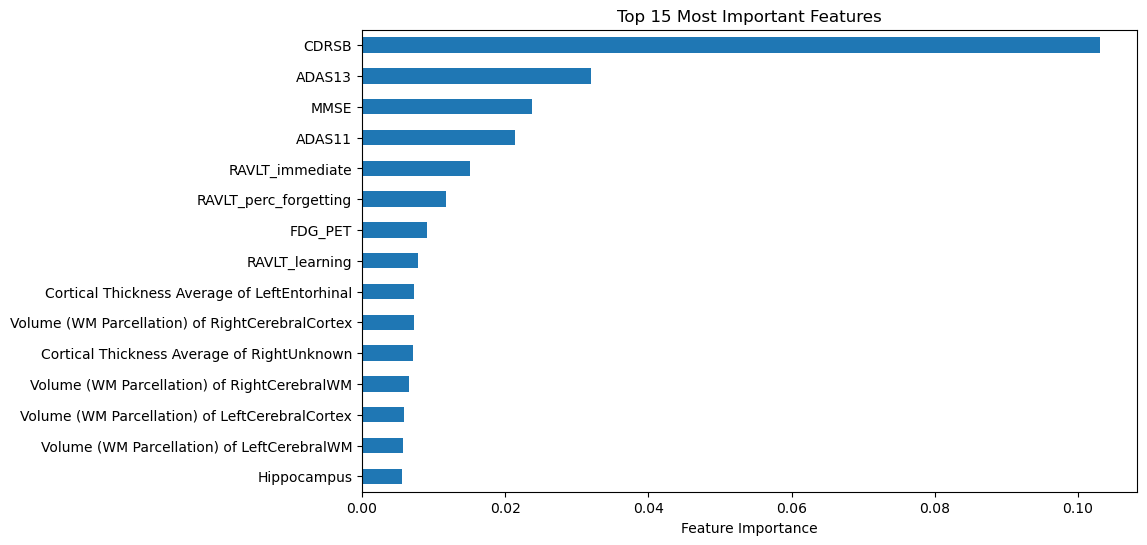

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features")
plt.show()

## Conclusion

In this project, a Random Forest classifier was trained to classify Alzheimer’s disease using clinical and cognitive test data.  
The dataset was cleaned, merged, standardised, and prepared for machine learning.  
The model achieved strong performance on both the training and testing sets, and further analysis using the confusion matrix and feature importance helped explain its behaviour.  
This project demonstrates how machine learning can be applied to medical data for disease classification.